## Analiza

In [1]:
import kagglehub

path = kagglehub.dataset_download("zubairdhuddi/student-dataset")

print("Path to dataset files:", path)

import pandas as pd
import os

files = os.listdir(path)
print("Pliki w folderze:", files)

csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)

df.head()

100%|██████████| 456k/456k [00:00<00:00, 24.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/zubairdhuddi/student-dataset/versions/1


Pliki w folderze: ['student_depression_dataset.csv']


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [3]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


## Brak brakujących danych na podstawie .info

In [4]:
import pandas as pd

numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['id', 'Depression'], errors='ignore')

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (numeric_df < lower_bound) | (numeric_df > upper_bound)
outliers_count = outliers_mask.sum()

print("Liczba outlierów w poszczególnych kolumnach:")
print(outliers_count)

# Wypisanie wierszy zawierających outliery
outliers_df = df[outliers_mask.any(axis=1)]
print(f"\nŁączna liczba wierszy z przynajmniej jednym outlierem: {len(outliers_df)}")
display(outliers_df)

Liczba outlierów w poszczególnych kolumnach:
Age                   12
Academic Pressure      0
Work Pressure          3
CGPA                   9
Study Satisfaction     0
Job Satisfaction       8
Work/Study Hours       0
dtype: int64

Łączna liczba wierszy z przynajmniej jednym outlierem: 23


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
292,1428,Male,29.0,Srinagar,Student,3.0,0.0,9.63,3.0,3.0,'7-8 hours',Moderate,M.Pharm,No,8.0,5.0,No,0
2909,14768,Female,58.0,Chennai,Student,4.0,0.0,8.58,1.0,0.0,'7-8 hours',Healthy,'Class 12',No,4.0,4.0,No,0
3436,17213,Male,49.0,Nagpur,Student,3.0,0.0,6.47,3.0,0.0,'5-6 hours',Moderate,'Class 12',Yes,2.0,1.0,Yes,0
4365,21880,Male,38.0,Chennai,Student,0.0,5.0,0.00,0.0,4.0,'5-6 hours',Healthy,'Class 12',No,2.0,3.0,No,0
4386,22004,Female,51.0,Bhopal,Student,2.0,0.0,8.26,3.0,0.0,'Less than 5 hours',Moderate,MBBS,Yes,5.0,5.0,Yes,0
5537,27918,Female,44.0,Srinagar,Student,1.0,0.0,6.83,3.0,0.0,'Less than 5 hours',Unhealthy,BSc,No,4.0,3.0,No,0
9006,45393,Male,46.0,Nashik,Student,1.0,0.0,6.10,3.0,0.0,'7-8 hours',Unhealthy,PhD,No,4.0,2.0,No,0
9238,46602,Male,59.0,Nashik,Student,1.0,0.0,8.14,1.0,0.0,'5-6 hours',Unhealthy,PhD,Yes,10.0,4.0,Yes,0
10407,52737,Male,28.0,Vadodara,Student,3.0,0.0,0.00,4.0,0.0,'Less than 5 hours',Healthy,BBA,No,12.0,2.0,No,0
11489,58062,Female,32.0,Vadodara,Student,5.0,0.0,0.00,0.0,0.0,'Less than 5 hours',Unhealthy,'Class 12',Yes,11.0,5.0,No,1


Usuwanie wierszy z outlierami, bo jest to tylko 0,08% danych essa

In [5]:
df_cleaned = df[~outliers_mask.any(axis=1)].copy().reset_index(drop=True)

print(f"Liczba wierszy przed usunięciem: {len(df)}")
print(f"Liczba wierszy po usunięciu: {len(df_cleaned)}")

df = df_cleaned

Liczba wierszy przed usunięciem: 27901
Liczba wierszy po usunięciu: 27878


### Statystyki opisowe (numeryczne)

In [6]:
# Statystyki dla zmiennych numerycznych
display(df.describe())

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27878.000000,27878.000000,27878.000000,27878.0,27878.000000,27878.000000,27878.0,27878.000000,27878.000000
mean,70442.056532,25.811536,3.142155,0.0,7.658491,2.944401,0.0,7.157795,0.585731
std,40640.340415,4.878066,1.380840,0.0,1.464565,1.360482,0.0,3.707326,0.492604
min,2.000000,18.000000,0.000000,0.0,5.030000,0.000000,0.0,0.000000,0.000000
25%,35040.750000,21.000000,2.000000,0.0,6.290000,2.000000,0.0,4.000000,0.000000
50%,70697.000000,25.000000,3.000000,0.0,7.770000,3.000000,0.0,8.000000,1.000000
75%,105817.000000,30.000000,4.000000,0.0,8.920000,4.000000,0.0,10.000000,1.000000
max,140699.000000,43.000000,5.000000,0.0,10.000000,5.000000,0.0,12.000000,1.000000


### Rozkłady zmiennych kategorycznych

In [7]:
# Analiza zmiennych kategorycznych
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"--- Rozkład dla kolumny: {col} ---")
    display(df[col].value_counts())
    print("\n")

--- Rozkład dla kolumny: Gender ---


,count
Gender,
Male,15535
Female,12343




--- Rozkład dla kolumny: City ---


,count
City,
Kalyan,1570
Srinagar,1370
Hyderabad,1340
Vasai-Virar,1290
Lucknow,1153
Thane,1139
Ludhiana,1110
Agra,1093
Surat,1077




--- Rozkład dla kolumny: Profession ---


...

,count
Have you ever had suicidal thoughts ?,
Yes,17644
No,10234




--- Rozkład dla kolumny: Financial Stress ---


,count
Financial Stress,
5.0,6708
4.0,5769
3.0,5220
1.0,5119
2.0,5059
?,3




--- Rozkład dla kolumny: Family History of Mental Illness ---


,count
Family History of Mental Illness,
No,14385
Yes,13493


In [8]:
# Wyrzucamy zawód, bo >99% to studenci
# Wyrzucamy Work pressure i Job Satisfaction, bo wartości to same 0
df = df.drop(columns = ['Work Pressure', 'Job Satisfaction', 'Profession'])


# Wyrzucamy miasta, gdzie liczebność jest mniejsza od 2
city_counts = df['City'].value_counts()
cities_to_keep = city_counts[city_counts > 2].index
df = df[df['City'].isin(cities_to_keep)]

# Wyrzucamy nieznane wartości
df = df[df['Sleep Duration'].str.lower() != 'others']
df = df[df['Dietary Habits'].str.lower() != 'others']
df = df[df['Degree'].str.lower() != 'others']
df = df[df['Financial Stress'] != '?']

df = df.reset_index(drop=True)

print(f"Liczba wierszy po czyszczeniu: {len(df)}")
display(df.head())

Liczba wierszy po czyszczeniu: 27784


,id,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,5.0,8.97,2.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,2.0,5.90,5.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,3.0,7.03,5.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,3.0,5.59,2.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,4.0,8.13,3.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


**Wizualizacja**

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(
    style="darkgrid",
    palette="bright"
)

# Initialize lists for features
numeric_features = []
categorical_features = []

# Populate feature lists, skipping 'id' column
for col in df.columns:
    if col == 'id': # Skip 'id' column as it's an identifier
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        numeric_features.append(col)
    elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
        categorical_features.append(col)
    else:
        print(f"Skipping column '{col}' due to unsupported data type: {df[col].dtype}")

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)


Numerical Features: ['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Depression']
Categorical Features: ['Gender', 'City', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']


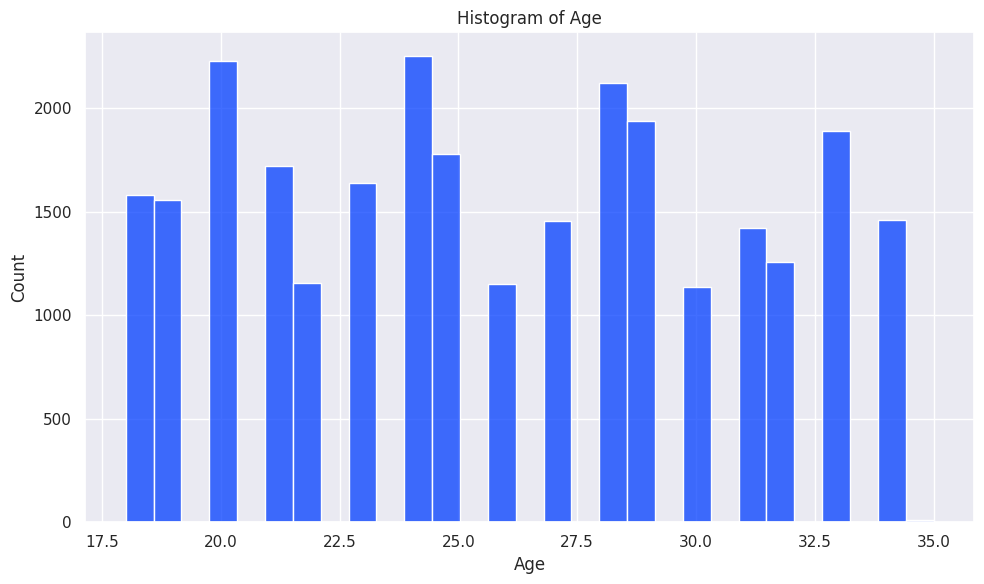

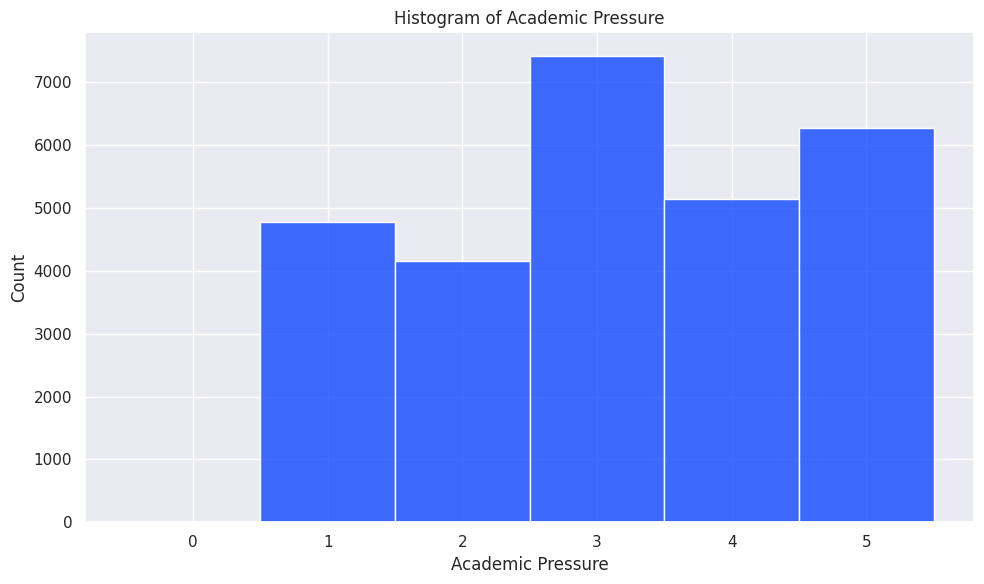

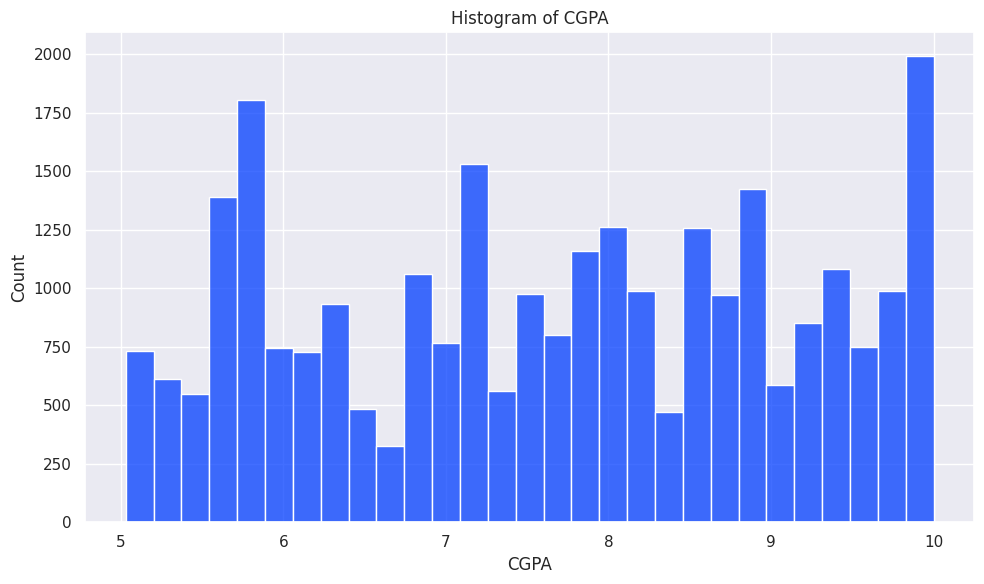

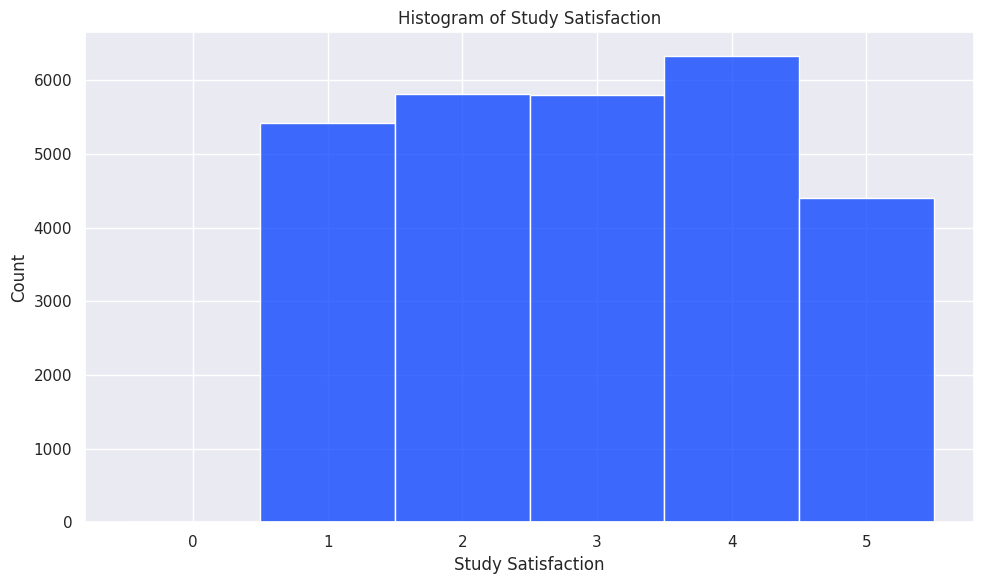

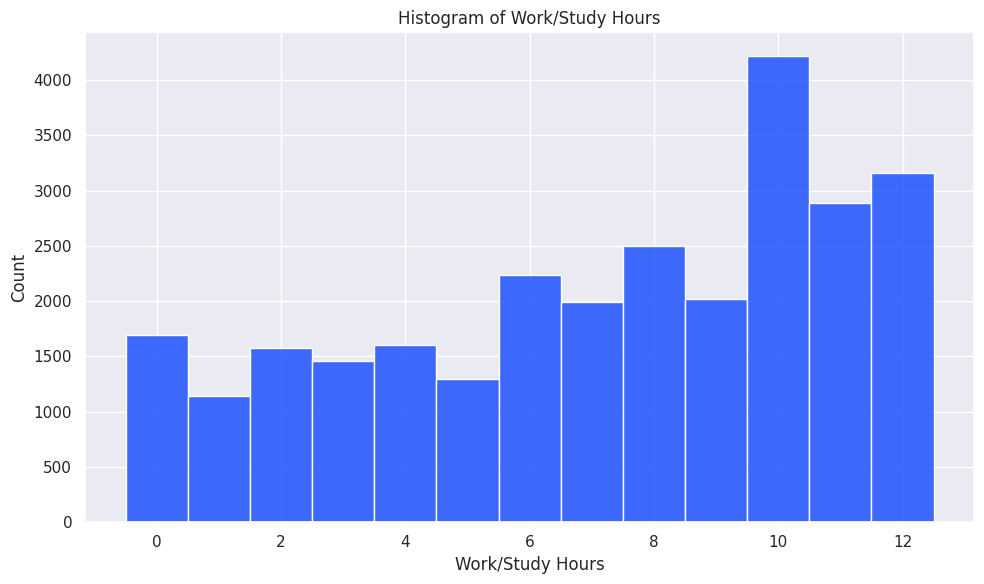

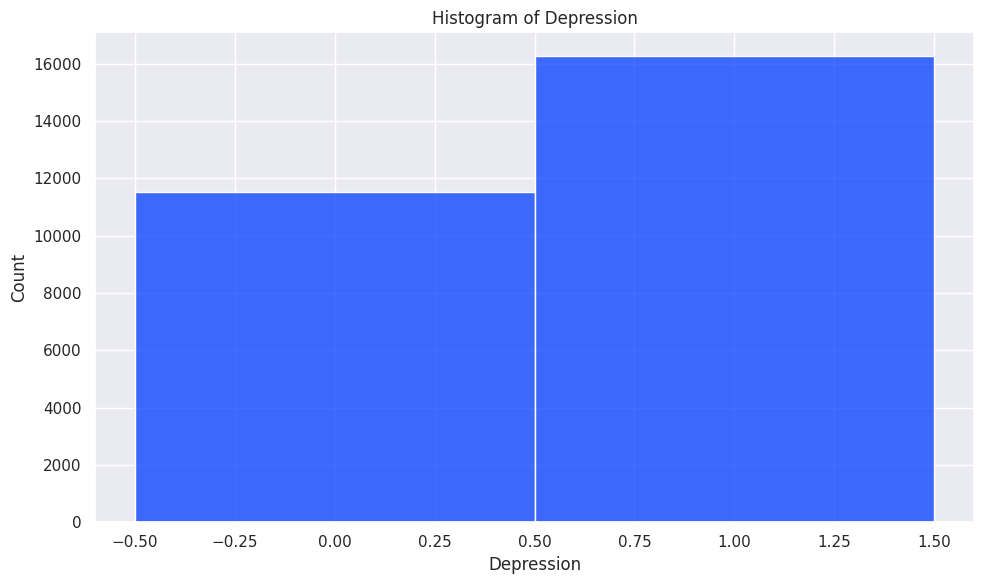

In [10]:
discrete_numeric_features = [
    'Academic Pressure', 'Work Pressure', 'Study Satisfaction',
    'Job Satisfaction', 'Work/Study Hours', 'Depression'
]

for cecha in numeric_features:
    plt.figure(figsize=(10, 6))
    current_df = df.copy()

    if cecha == 'Age':
        current_df = current_df[current_df['Age'] <= 35]

    if cecha in discrete_numeric_features:
        sns.histplot(data=current_df, x=cecha, discrete=True)
    else:
        sns.histplot(data=current_df, x=cecha)
    plt.title(f'Histogram of {cecha}')
    plt.xlabel(cecha)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

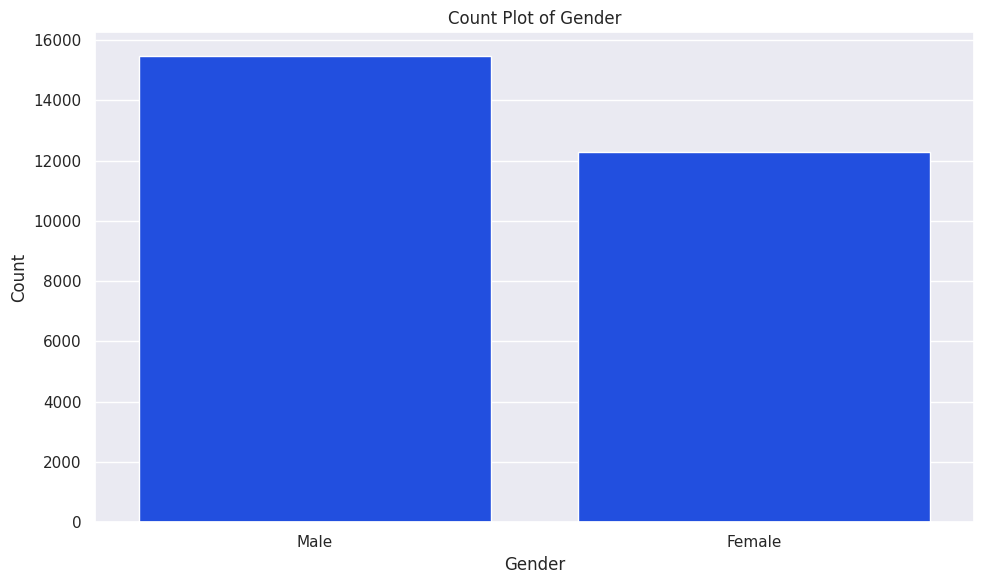

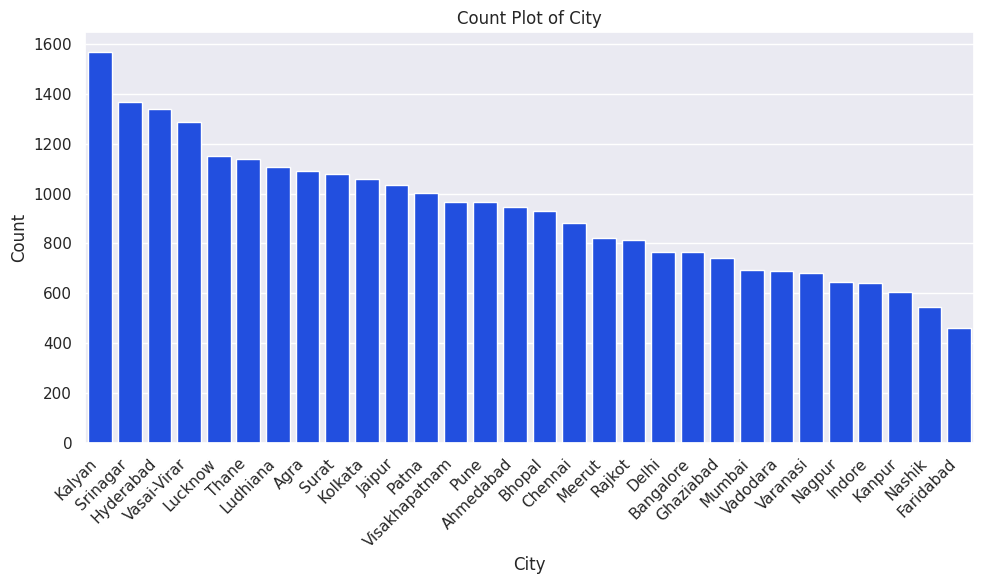

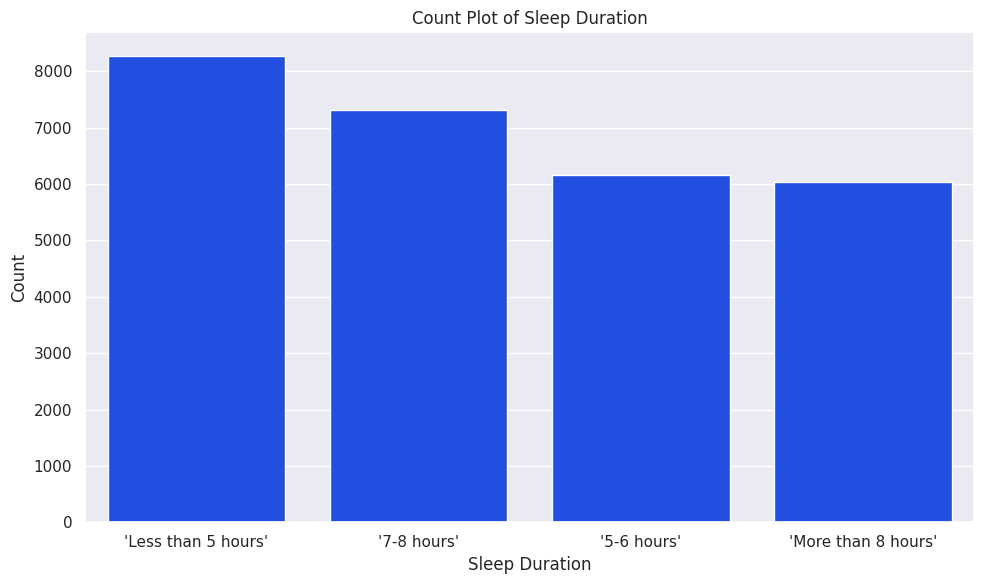

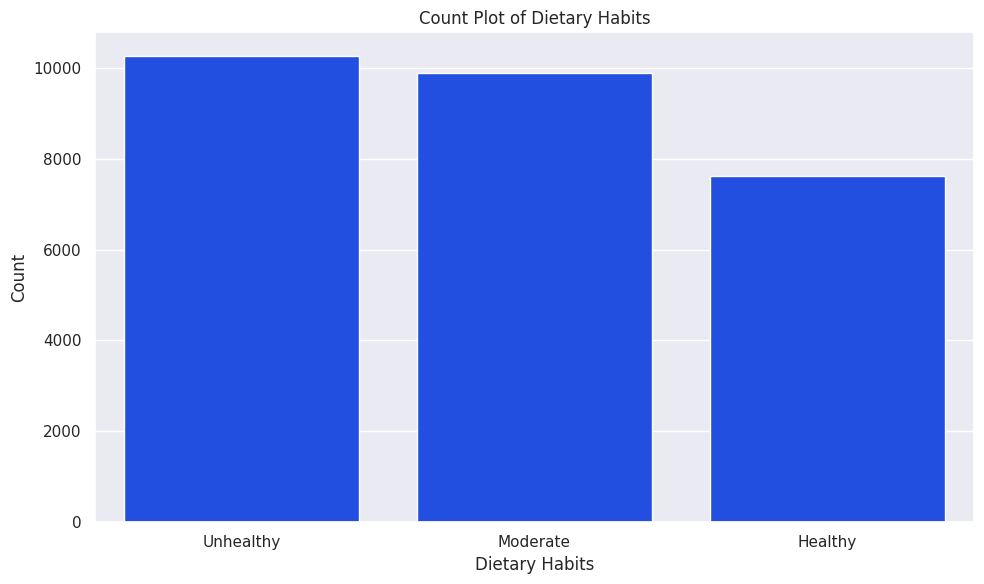

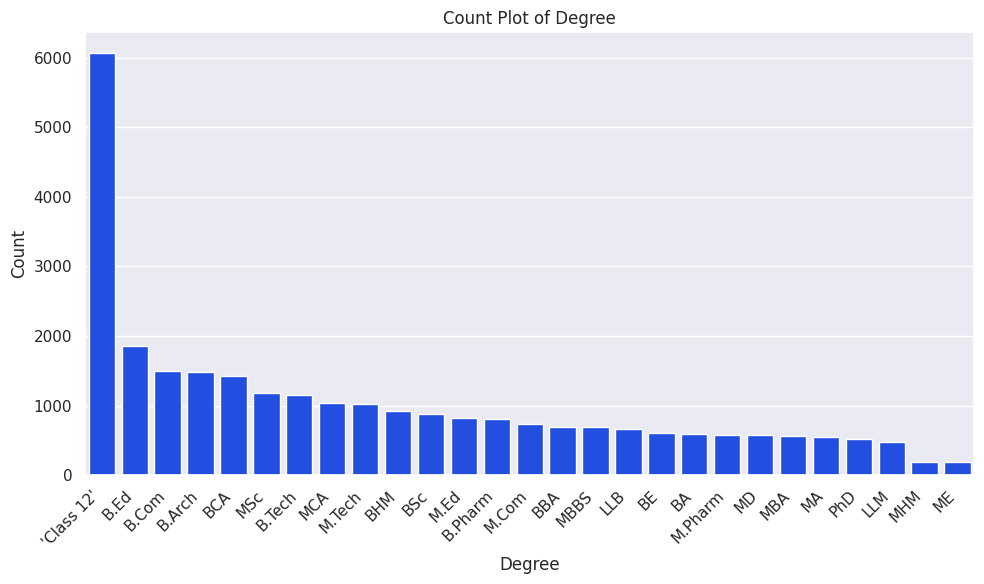

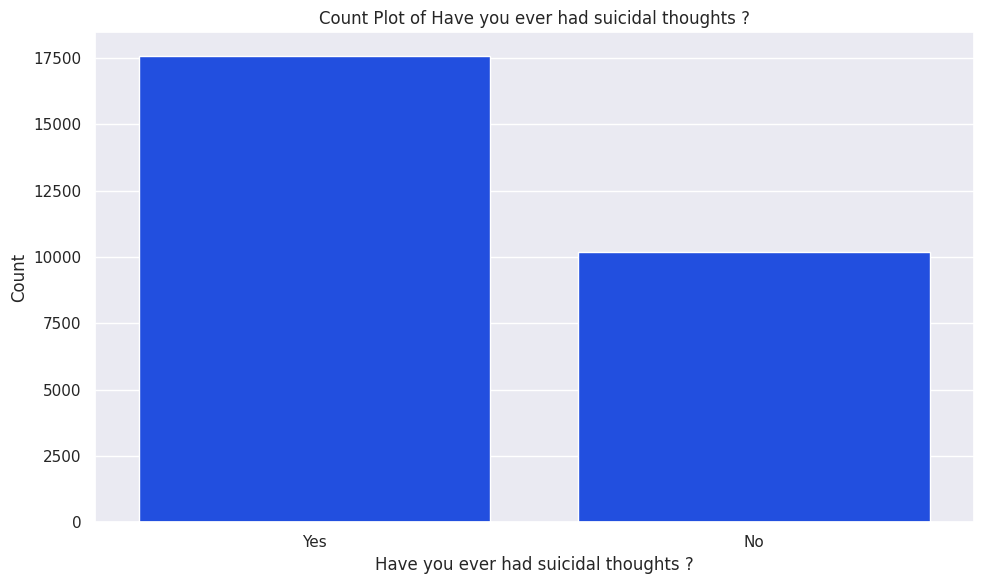

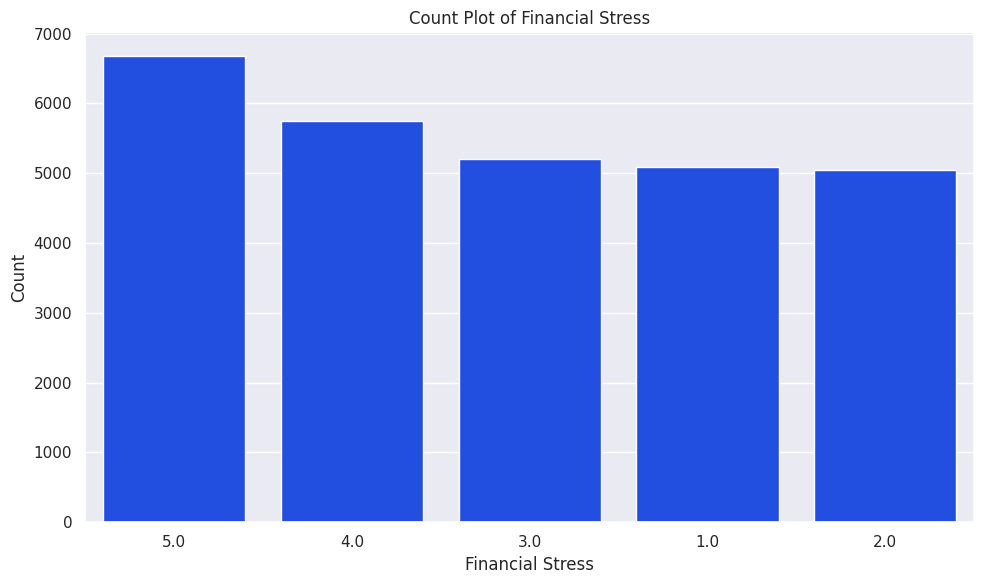

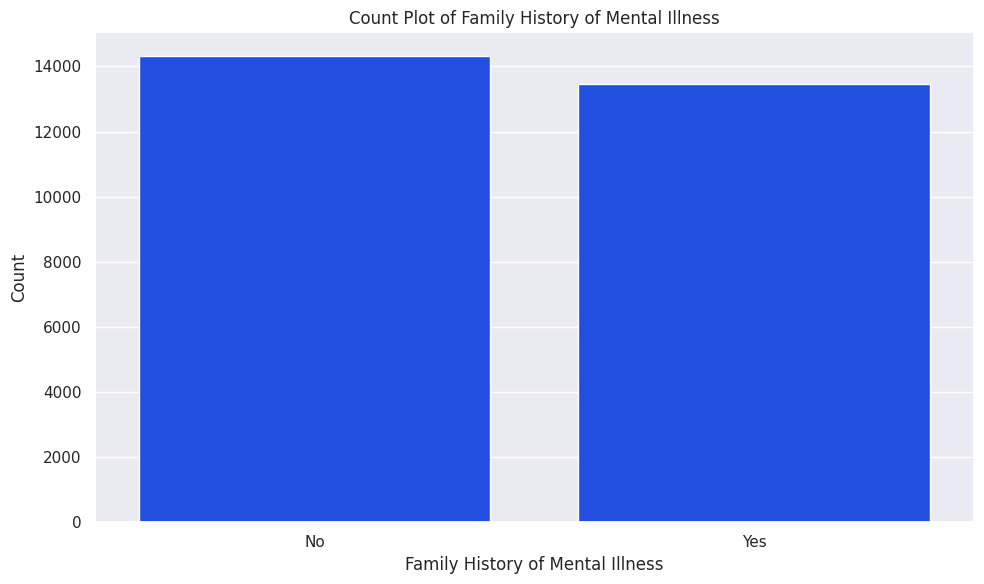

In [11]:
for cecha in categorical_features:
    plt.figure(figsize=(10, 6))
    # Order categories by their counts for better readability
    sns.countplot(data=df, x=cecha, order=df[cecha].value_counts().index)
    plt.title(f'Count Plot of {cecha}')
    plt.xlabel(cecha)
    plt.ylabel('Count')
    # Rotate x-axis labels if there are many categories to prevent overlap
    if df[cecha].nunique() > 5:
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [12]:
import numpy as np
from scipy import stats
import pandas as pd # Ensure pandas is imported for pd.to_numeric

cechy_do_badania = ['Academic Pressure', 'CGPA', 'Study Satisfaction', 'Age', 'Work/Study Hours', 'Depression']

print(" Analiza rozkładów cech numerycznych \n")
for feature in cechy_do_badania:
    print(f"--- {feature} ---")

    # Skewness and Kurtosis
    skewness = df[feature].skew()
    kurtosis = df[feature].kurt()
    print(f"Skośność: {skewness:.4f}")
    print(f"Kurtoza: {kurtosis:.4f}")

    valid_data = df[feature].dropna()
    stat, p = stats.normaltest(valid_data)
    print(f"Test normalności (D'Agostino): Statystyka={stat:.4f}, p-wartość={p:.4f}")
    if p < 0.05:  # alpha = 0.05
        print("Rozkład prawdopodobnie nie jest normalny (p < 0.05)")
    else:
        print("Brak dowodów, by odrzucić hipotezę o normalności (p >= 0.05)")

    # Outliers
    print(f"Min: {df[feature].min()}, Max: {df[feature].max()}\n")


 Analiza rozkładów cech numerycznych 

--- Academic Pressure ---
Skośność: -0.1354
Kurtoza: -1.1635
Test normalności (D'Agostino): Statystyka=18032.5133, p-wartość=0.0000
Rozkład prawdopodobnie nie jest normalny (p < 0.05)
Min: 0.0, Max: 5.0

--- CGPA ---
Skośność: -0.0735
Kurtoza: -1.2296
Test normalności (D'Agostino): Statystyka=33056.6576, p-wartość=0.0000
Rozkład prawdopodobnie nie jest normalny (p < 0.05)
Min: 5.03, Max: 10.0

--- Study Satisfaction ---
Skośność: 0.0112
Kurtoza: -1.2246
Test normalności (D'Agostino): Statystyka=31286.6920, p-wartość=0.0000
Rozkład prawdopodobnie nie jest normalny (p < 0.05)
Min: 0.0, Max: 5.0

--- Age ---
Skośność: 0.0791
Kurtoza: -1.1517
Test normalności (D'Agostino): Statystyka=16425.1553, p-wartość=0.0000
Rozkład prawdopodobnie nie jest normalny (p < 0.05)
Min: 18.0, Max: 43.0

--- Work/Study Hours ---
Skośność: -0.4567
Kurtoza: -0.9967
Test normalności (D'Agostino): Statystyka=7140.5045, p-wartość=0.0000
Rozkład prawdopodobnie nie jest normaln

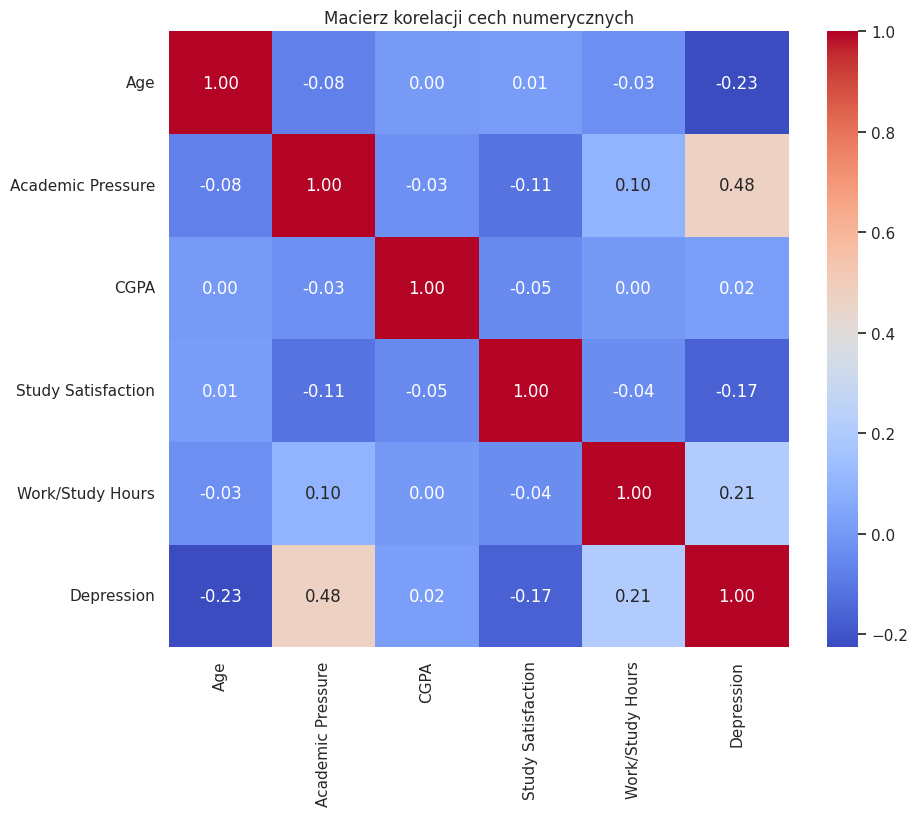

In [13]:

correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji cech numerycznych')
plt.show()

### Zależności między cechami numerycznymi a depresją

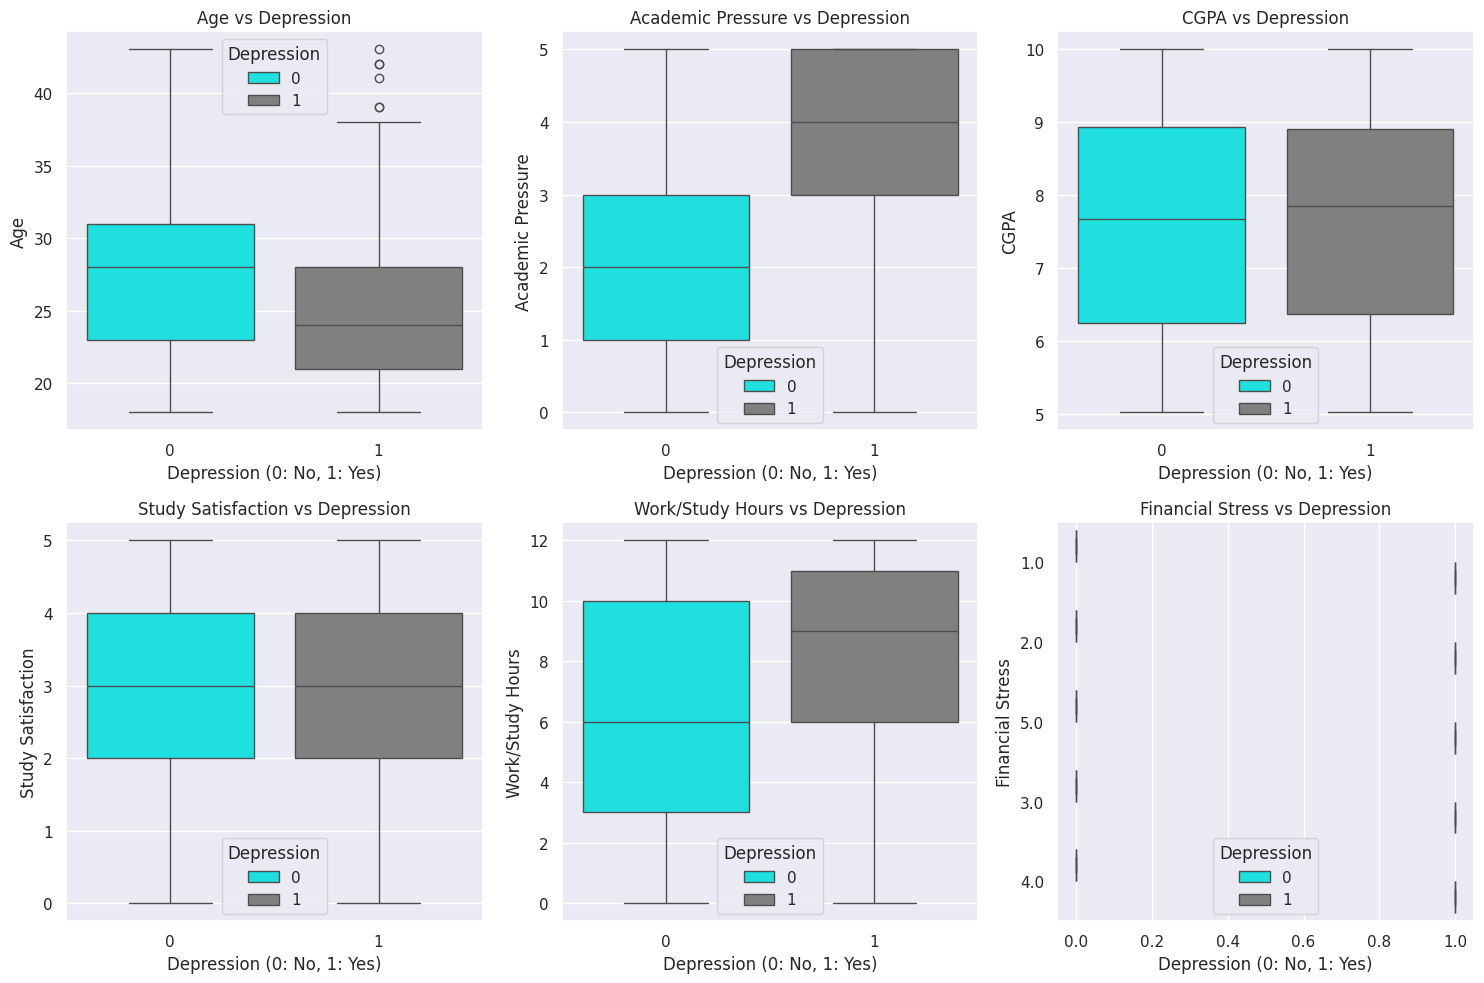

In [14]:
numerical_explanatory_features = ['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_explanatory_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Depression', y=feature, data=df, hue='Depression', palette={0: 'cyan', 1: 'gray'})
    plt.title(f'{feature} vs Depression')
    plt.xlabel('Depression (0: No, 1: Yes)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Zależności między cechami kategorycznymi a depresją

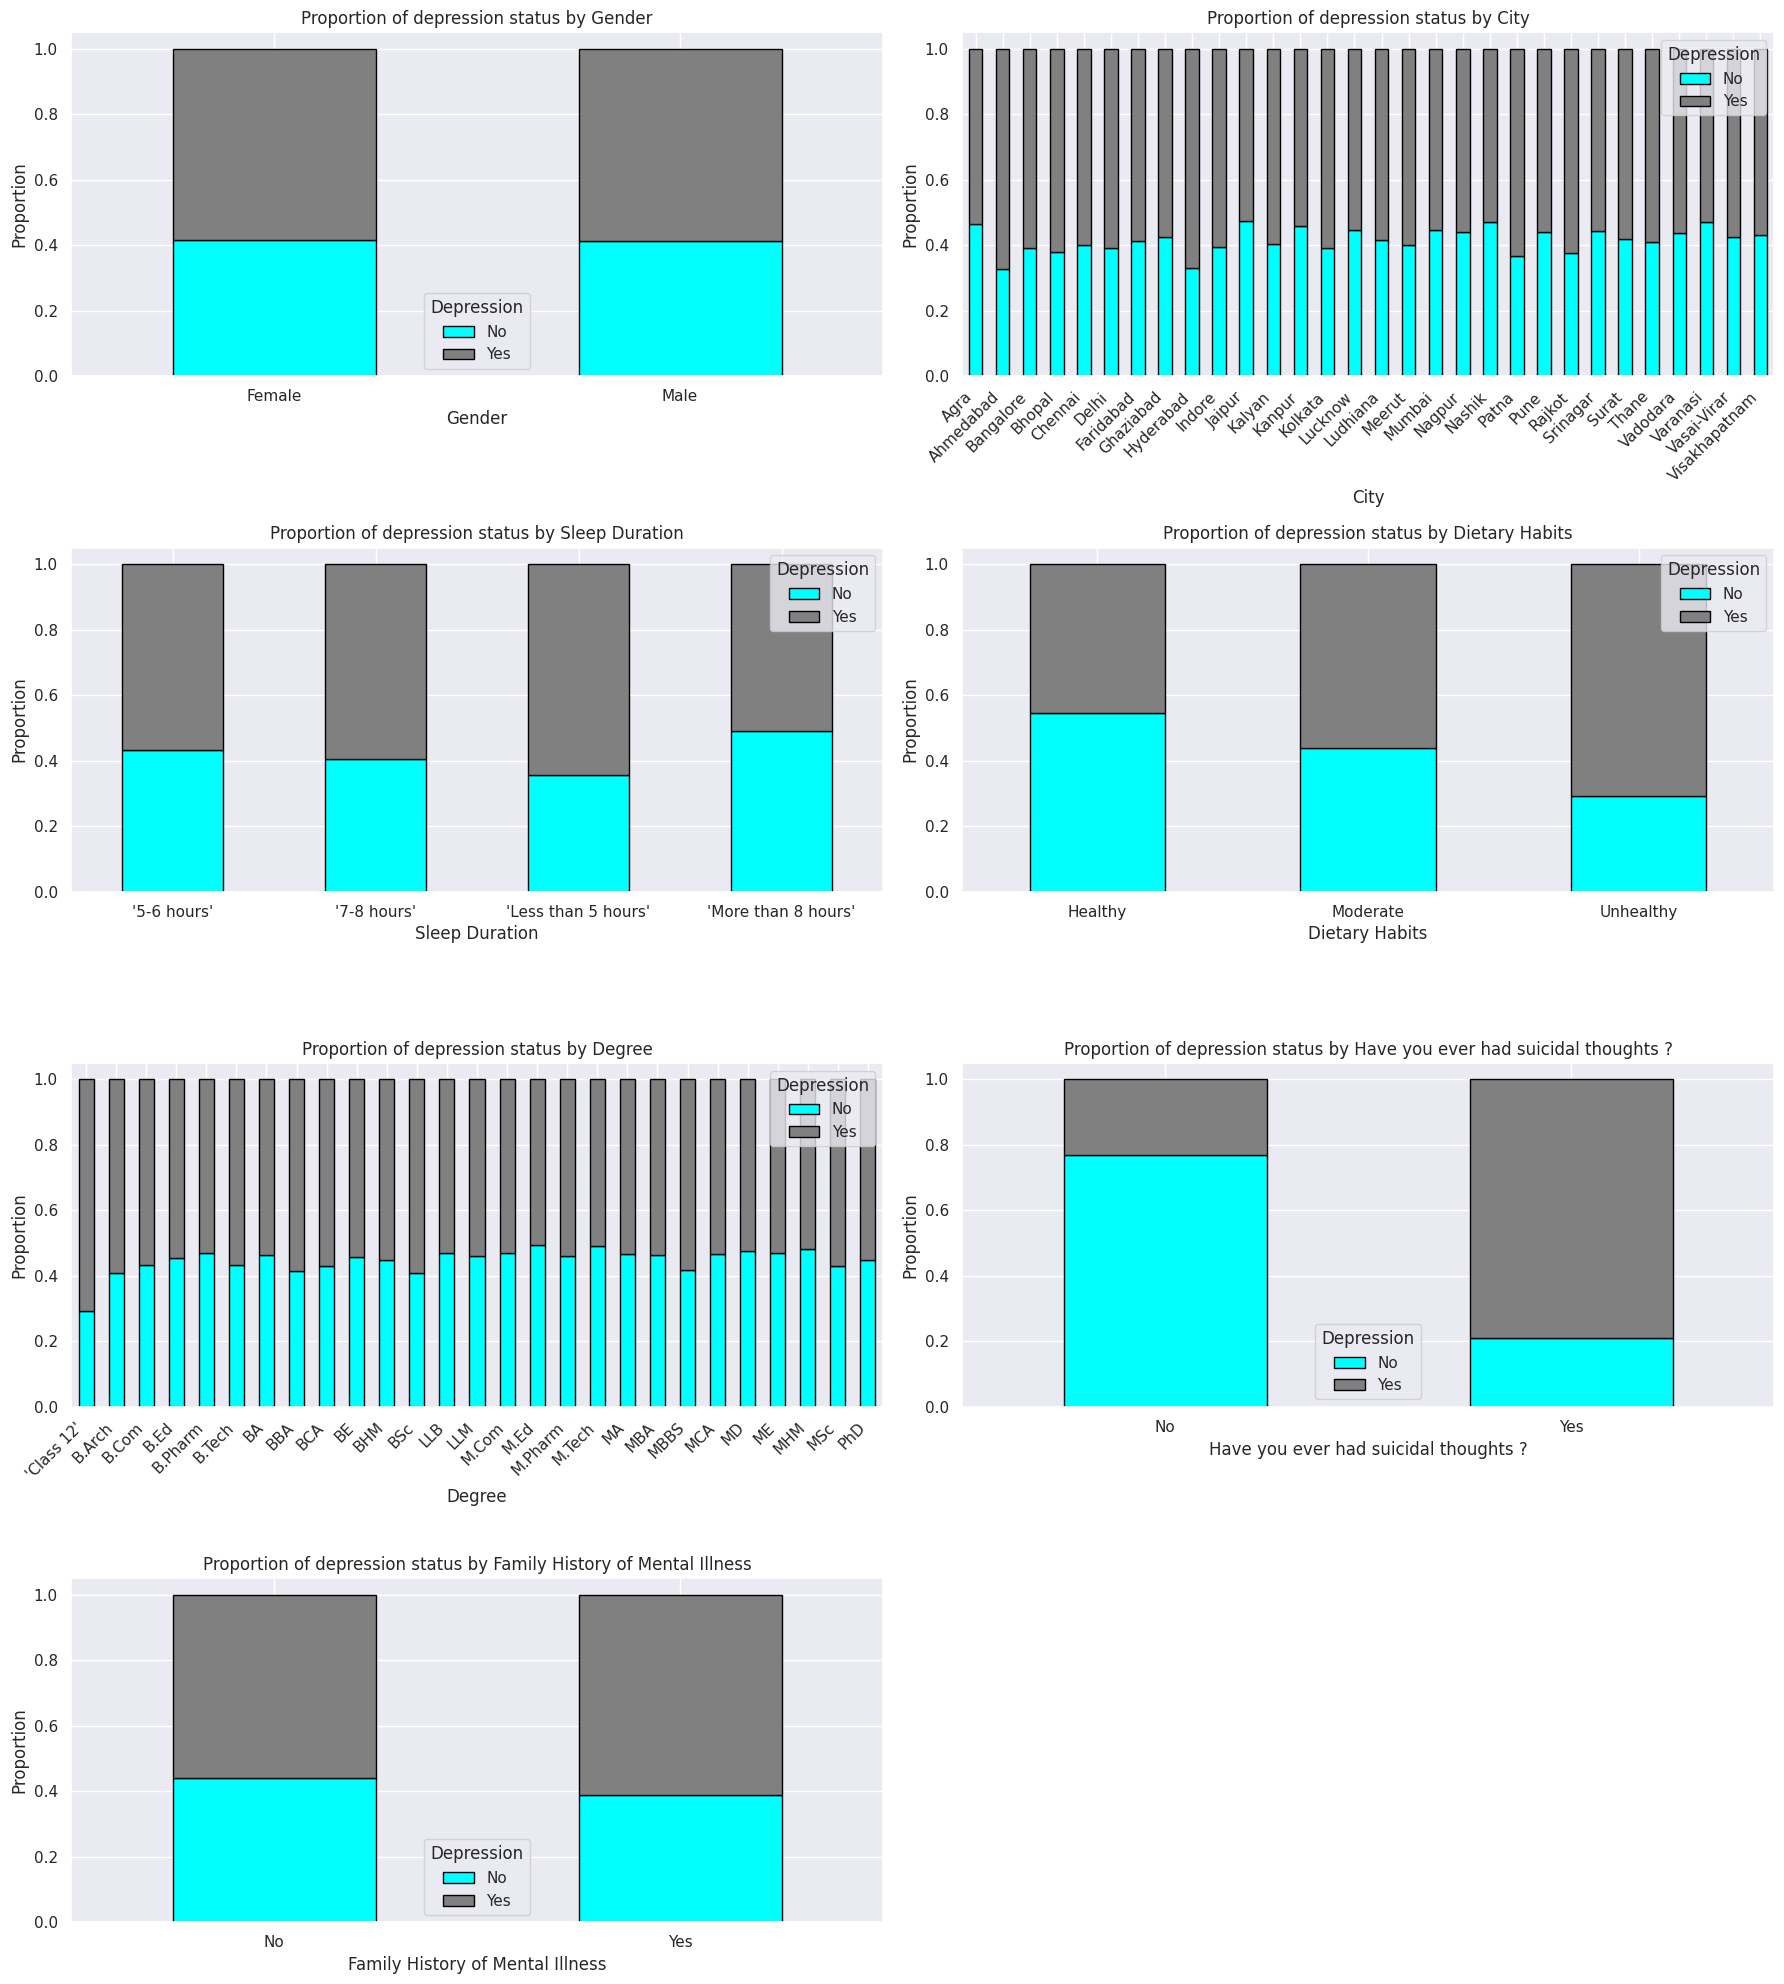

In [15]:
categorical_explanatory_features = ['Gender', 'City', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

plt.figure(figsize=(18, 20))
for i, feature in enumerate(categorical_explanatory_features):
    plt.subplot(4, 2, i + 1)

    proportions = df.groupby(feature)['Depression'].value_counts(normalize=True).unstack(fill_value=0)

    proportions.plot(kind='bar', stacked=True, ax=plt.gca(), color=['cyan', 'gray'], edgecolor='black')

    plt.title(f'Proportion of depression status by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Proportion')

    if df[feature].nunique() > 5:
        plt.xticks(rotation=45, ha='right')
    else:
        plt.xticks(rotation=0) # Keep labels horizontal for fewer categories

    plt.legend(title='Depression', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

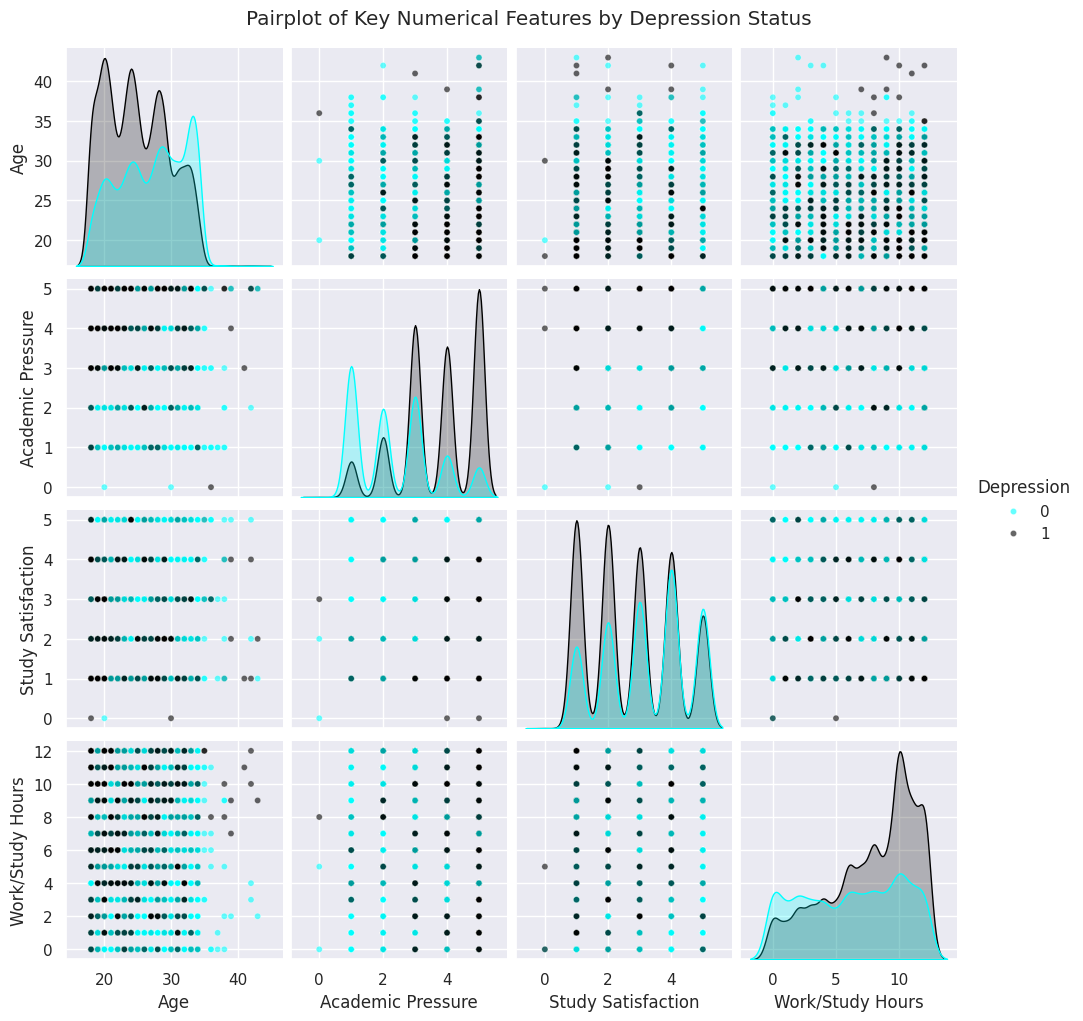

In [16]:
selected_features_for_pairplot = [
    'Age',
    'Academic Pressure',
    'Study Satisfaction',
    'Work/Study Hours',
    'Depression'
]

sns.pairplot(df[selected_features_for_pairplot], hue='Depression', palette={0: 'cyan', 1: 'black'}, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Pairplot of Key Numerical Features by Depression Status', y=1.02)
plt.show()